In [ ]:
# Credit Card Approval Prediction System

### SmartBridge Internship Project

**Team Members**
- Aragonda Indra
- Kodirekka Sangeeth Babu

---

## Objective

The objective of this project is to build a machine learning model capable of predicting whether a credit card transaction/application belongs to the target class using multiple classification algorithms.

Algorithms Used:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

The best-performing model will be deployed using Flask for real-time prediction.

In [1]:
#Importing Required Libraries

import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Uploading Dataset

from google.colab import files

uploaded = files.upload()

Saving credit_record.csv to credit_record.csv
Saving application_record (3) (1).csv to application_record (3) (1).csv


In [ ]:
application = pd.read_csv("application_record (3) (1).csv")
credit = pd.read_csv("credit_record.csv")

print("Application Dataset Shape :", application.shape)
print("Credit Dataset Shape :", credit.shape)

Application Dataset Shape : (438557, 18)
Credit Dataset Shape : (1048575, 3)


In [ ]:
# Display First 5 Rows

print("Application Dataset")
display(application.head())

print("\nCredit Record Dataset")
display(credit.head())

Application Dataset


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0



Credit Record Dataset


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
# Dataset Information

print("Application Dataset Information")
application.info()

print("\n")

print("Credit Record Dataset Information")
credit.info()

Application Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null

In [ ]:
# Check Missing Values

print("Application Dataset Missing Values")
display(application.isnull().sum())

print("--------------------------------------")

print("Credit Dataset Missing Values")
display(credit.isnull().sum())

Application Dataset Missing Values


,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


--------------------------------------
Credit Dataset Missing Values


,0
ID,0
MONTHS_BALANCE,0
STATUS,0


In [ ]:
# Check Duplicate Records

print("Application Dataset Duplicate Records:", application.duplicated().sum())

print("Credit Dataset Duplicate Records:", credit.duplicated().sum())

Application Dataset Duplicate Records: 0
Credit Dataset Duplicate Records: 0


In [ ]:
# Merge Application & Credit Datasets

data = pd.merge(application, credit, on="ID", how="inner")

print("Merged Dataset Shape:", data.shape)

display(data.head())

Merged Dataset Shape: (777715, 20)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C


In [ ]:
# Create Target Variable

# Convert STATUS into Approval Label
data["TARGET"] = data["STATUS"].apply(
    lambda x: 1 if x in ["C", "X", "0"] else 0
)

# Display Target Distribution
print(data["TARGET"].value_counts())

display(data[["STATUS", "TARGET"]].head(15))

TARGET
1    766140
0     11575
Name: count, dtype: int64


,STATUS,TARGET
0,C,1
1,C,1
2,C,1
3,C,1
4,C,1
5,C,1
6,C,1
7,C,1
8,C,1
9,C,1


In [ ]:
# Remove Duplicate Customers

# Sort by latest month
data = data.sort_values(by="MONTHS_BALANCE")

# Keep latest record for each customer
data = data.drop_duplicates(subset="ID", keep="last")

print("Dataset Shape After Removing Duplicates:", data.shape)

display(data.head())

Dataset Shape After Removing Duplicates: (36457, 21)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,TARGET
199323,5041856,M,Y,N,0,112500.0,Pensioner,Secondary / secondary special,Civil marriage,House / apartment,...,365243,1,0,1,0,NaN,2.0,-60,0,1
196962,5041710,M,Y,Y,3,180000.0,Working,Secondary / secondary special,Married,House / apartment,...,-824,1,1,1,0,High skill tech staff,5.0,-59,X,1
213450,5045517,M,Y,N,1,180000.0,Working,Secondary / secondary special,Married,House / apartment,...,-4491,1,0,0,0,NaN,3.0,-59,0,1
406017,5079234,F,N,Y,0,112500.0,Working,Higher education,Single / not married,House / apartment,...,-3161,1,0,0,0,NaN,1.0,-59,0,1
155905,5035920,F,Y,Y,1,180000.0,Commercial associate,Incomplete higher,Civil marriage,House / apartment,...,-706,1,0,0,0,Laborers,3.0,-59,X,1


In [ ]:
# Drop Unnecessary Columns

data.drop(["ID", "STATUS", "MONTHS_BALANCE"], axis=1, inplace=True)

print("Updated Dataset Shape:", data.shape)

display(data.head())

Updated Dataset Shape: (36457, 18)


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
199323,M,Y,N,0,112500.0,Pensioner,Secondary / secondary special,Civil marriage,House / apartment,-21990,365243,1,0,1,0,NaN,2.0,1
196962,M,Y,Y,3,180000.0,Working,Secondary / secondary special,Married,House / apartment,-14192,-824,1,1,1,0,High skill tech staff,5.0,1
213450,M,Y,N,1,180000.0,Working,Secondary / secondary special,Married,House / apartment,-11498,-4491,1,0,0,0,NaN,3.0,1
406017,F,N,Y,0,112500.0,Working,Higher education,Single / not married,House / apartment,-14446,-3161,1,0,0,0,NaN,1.0,1
155905,F,Y,Y,1,180000.0,Commercial associate,Incomplete higher,Civil marriage,House / apartment,-15445,-706,1,0,0,0,Laborers,3.0,1


In [ ]:
# Missing Values

print(data.isnull().sum())

CODE_GENDER                0
FLAG_OWN_CAR               0
FLAG_OWN_REALTY            0
CNT_CHILDREN               0
AMT_INCOME_TOTAL           0
NAME_INCOME_TYPE           0
NAME_EDUCATION_TYPE        0
NAME_FAMILY_STATUS         0
NAME_HOUSING_TYPE          0
DAYS_BIRTH                 0
DAYS_EMPLOYED              0
FLAG_MOBIL                 0
FLAG_WORK_PHONE            0
FLAG_PHONE                 0
FLAG_EMAIL                 0
OCCUPATION_TYPE        11323
CNT_FAM_MEMBERS            0
TARGET                     0
dtype: int64


In [ ]:
# Fill Missing Values

data["OCCUPATION_TYPE"] = data["OCCUPATION_TYPE"].fillna("Unknown")

print("Missing Values After Filling")

print(data.isnull().sum())

Missing Values After Filling
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
FLAG_MOBIL             0
FLAG_WORK_PHONE        0
FLAG_PHONE             0
FLAG_EMAIL             0
OCCUPATION_TYPE        0
CNT_FAM_MEMBERS        0
TARGET                 0
dtype: int64


In [ ]:
# Feature Engineering

# Convert days into positive years
data["AGE"] = (-data["DAYS_BIRTH"]) // 365

# Convert employment duration into years
data["EMPLOYMENT_YEARS"] = (-data["DAYS_EMPLOYED"]) // 365

# Drop original columns
data.drop(["DAYS_BIRTH", "DAYS_EMPLOYED"], axis=1, inplace=True)

display(data.head())

,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,EMPLOYMENT_YEARS
199323,M,Y,N,0,112500.0,Pensioner,Secondary / secondary special,Civil marriage,House / apartment,1,0,1,0,Unknown,2.0,1,60,-1001
196962,M,Y,Y,3,180000.0,Working,Secondary / secondary special,Married,House / apartment,1,1,1,0,High skill tech staff,5.0,1,38,2
213450,M,Y,N,1,180000.0,Working,Secondary / secondary special,Married,House / apartment,1,0,0,0,Unknown,3.0,1,31,12
406017,F,N,Y,0,112500.0,Working,Higher education,Single / not married,House / apartment,1,0,0,0,Unknown,1.0,1,39,8
155905,F,Y,Y,1,180000.0,Commercial associate,Incomplete higher,Civil marriage,House / apartment,1,0,0,0,Laborers,3.0,1,42,1


In [ ]:
# Encode Categorical Features and Save Encoders

from sklearn.preprocessing import LabelEncoder
import joblib

encoders = {}

categorical_columns = data.select_dtypes(include="object").columns

for column in categorical_columns:
    encoder = LabelEncoder()
    data[column] = encoder.fit_transform(data[column])
    encoders[column] = encoder

print("Encoding Completed Successfully")

display(data.head())

Encoding Completed Successfully


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET,AGE,EMPLOYMENT_YEARS
199323,1,1,0,0,112500.0,1,4,0,1,1,0,1,0,17,2.0,1,60,-1001
196962,1,1,1,3,180000.0,4,4,1,1,1,1,1,0,6,5.0,1,38,2
213450,1,1,0,1,180000.0,4,4,1,1,1,0,0,0,17,3.0,1,31,12
406017,0,0,1,0,112500.0,4,1,3,1,1,0,0,0,17,1.0,1,39,8
155905,0,1,1,1,180000.0,0,2,0,1,1,0,0,0,8,3.0,1,42,1


In [ ]:
import joblib
import os

joblib.dump(encoders, "encoders.pkl")

print("Encoders:", len(encoders))
print("Columns:", list(encoders.keys()))
print("File size:", os.path.getsize("encoders.pkl"), "bytes")

Encoders: 8
Columns: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']
File size: 2766 bytes


In [ ]:
# Split Features and Target

X = data.drop("TARGET", axis=1)

y = data["TARGET"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (36457, 17)
Target Shape: (36457,)


In [ ]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,      # 20% data for testing
    random_state=42,     # Ensures reproducibility
    stratify=y           # Maintains class distribution
)

# Display the shape of training and testing datasets
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (29165, 17)
Testing Data Shape: (7292, 17)


In [ ]:
# Balance the training data using SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("Balanced Training Data Shape:", X_train.shape)
print("Balanced Target Distribution:")
print(y_train.value_counts())

Balanced Training Data Shape: (57718, 17)
Balanced Target Distribution:
TARGET
1    28859
0    28859
Name: count, dtype: int64


In [ ]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [ ]:
# Import Machine Learning Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score

In [ ]:
# Logistic Regression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.7368348875479978


In [ ]:
# Decision Tree

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.978332419089413


In [ ]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9670872188699945


In [ ]:
# XGBoost

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9725726823916621


In [ ]:
# Compare Model Accuracy

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

display(results)

,Model,Accuracy
1,Decision Tree,0.978332
3,XGBoost,0.972573
2,Random Forest,0.967087
0,Logistic Regression,0.736835


In [ ]:
# Save Best Model

import joblib

joblib.dump(dt, "best_model.pkl")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(encoders, "encoders.pkl")

print("Encoders Saved Successfully")
print("Best Model Saved Successfully")

Encoders Saved Successfully
Best Model Saved Successfully


In [ ]:
from google.colab import files

files.download("best_model.pkl")
files.download("scaler.pkl")
files.download("encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

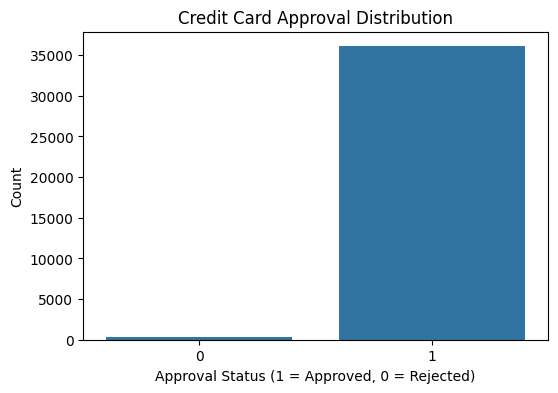

In [ ]:
# Count Plot of Approval Status

plt.figure(figsize=(6,4))

sns.countplot(x="TARGET", data=data)

plt.title("Credit Card Approval Distribution")

plt.xlabel("Approval Status (1 = Approved, 0 = Rejected)")

plt.ylabel("Count")

plt.show()

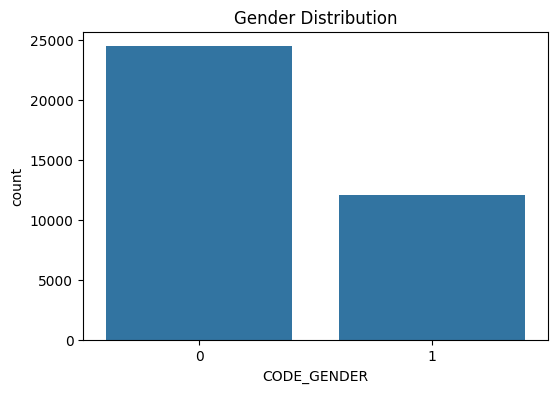

In [ ]:
# Gender Distribution

plt.figure(figsize=(6,4))

sns.countplot(x="CODE_GENDER", data=data)

plt.title("Gender Distribution")

plt.show()

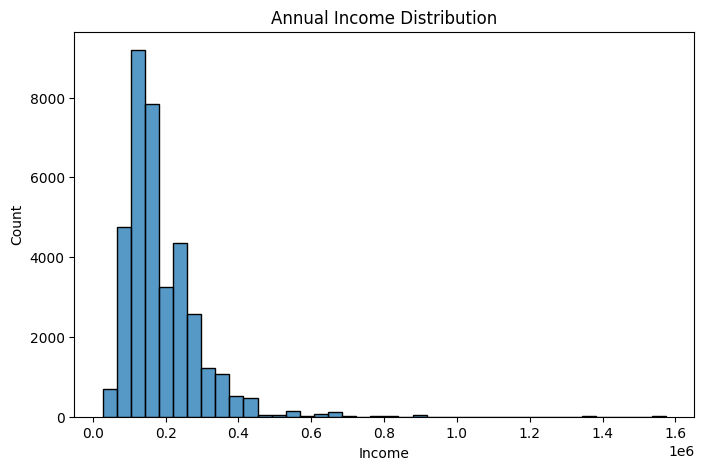

In [ ]:
# Annual Income Distribution

plt.figure(figsize=(8,5))

sns.histplot(data["AMT_INCOME_TOTAL"], bins=40)

plt.title("Annual Income Distribution")

plt.xlabel("Income")

plt.show()

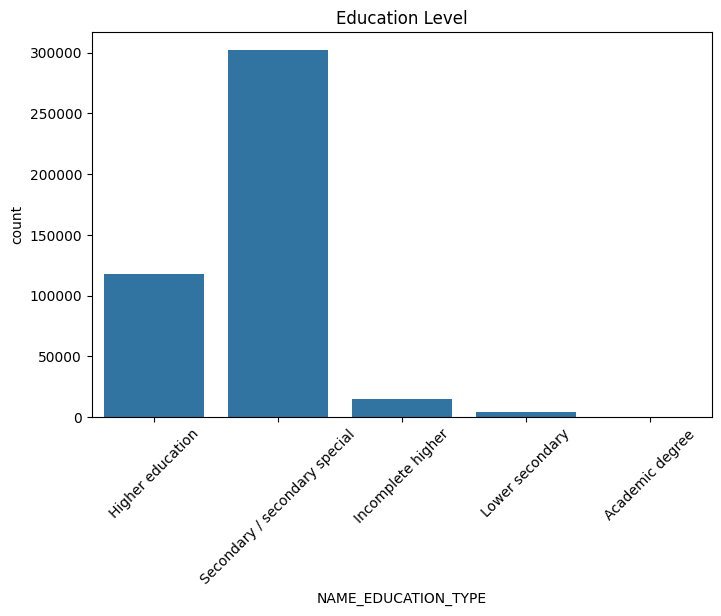

In [ ]:
# Education Level Distribution

plt.figure(figsize=(8,5))

sns.countplot(x="NAME_EDUCATION_TYPE", data=application)

plt.xticks(rotation=45)

plt.title("Education Level")

plt.show()

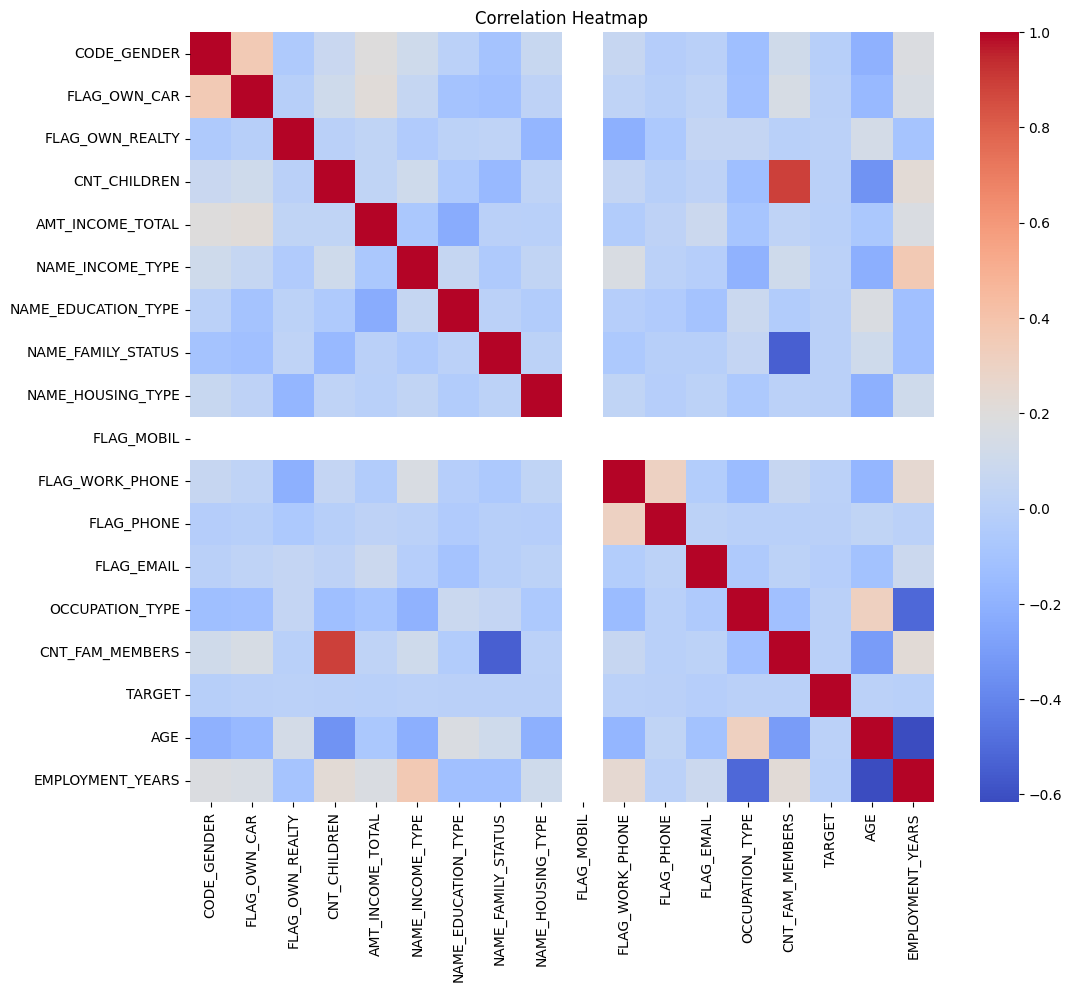

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(12,10))

sns.heatmap(data.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

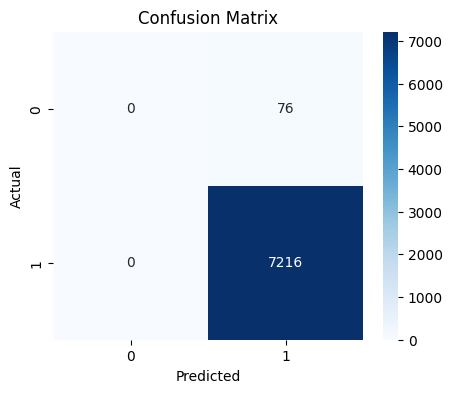

In [ ]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        76
           1       0.99      1.00      0.99      7216

    accuracy                           0.99      7292
   macro avg       0.49      0.50      0.50      7292
weighted avg       0.98      0.99      0.98      7292



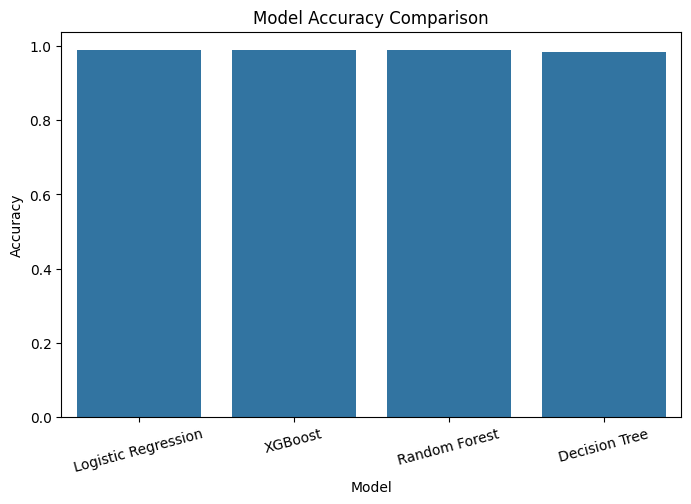

In [ ]:
# Accuracy Comparison

plt.figure(figsize=(8,5))

sns.barplot(data=results,
            x="Model",
            y="Accuracy")

plt.title("Model Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()